## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('penguins_data.csv')
df.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [5]:
print("Количество нулей по столбцам:")
print(df.isnull().sum())

print("Перед удалением пропусков форма датафрейма: ", df.shape)

df.dropna(axis=0, inplace=True)
print("После удаления:", df.shape)

# Нельзя ввести отношение порядка между этими признаками, вопспользуемся one hot encoding
categorical_features = ["Island", "Clutch Completion", "Sex"]
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

Количество нулей по столбцам:
Species                 0
Island                  0
Clutch Completion       0
Date Egg                0
Culmen Length (mm)      2
Culmen Depth (mm)       2
Flipper Length (mm)     2
Body Mass (g)           2
Sex                    10
Delta 15 N (o/oo)      14
Delta 13 C (o/oo)      13
dtype: int64
Перед удалением пропусков форма датафрейма:  (344, 11)
После удаления: (325, 11)


Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [10]:
species_map = {"Chinstrap": 0, "Gentoo": 1, "Adelie": 2}
df_encoded["Species"] = df["Species"].map(species_map)

print("После манипуляций:")
print(df_encoded.head())

После манипуляций:
   Species  Date Egg  Culmen Length (mm)  Culmen Depth (mm)  \
0        0       382                50.9               19.1   
1        0       741                45.2               17.8   
2        1       744                46.5               13.5   
3        0        10                45.2               16.6   
4        1        13                48.4               14.4   

   Flipper Length (mm)  Body Mass (g)  Delta 15 N (o/oo)  Delta 13 C (o/oo)  \
0                196.0         3550.0           10.02372          -24.86594   
1                198.0         3950.0            8.88942          -24.49433   
2                210.0         4550.0            7.99530          -25.32829   
3                191.0         3250.0            9.62357          -24.78984   
4                203.0         4625.0            8.16582          -26.13971   

   Island_Dream  Island_Torgersen  Clutch Completion_Yes  Sex_FEMALE  Sex_MALE  
0          True             False             

**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [33]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

from sklearn.model_selection import train_test_split

y = df_encoded["Species"].values
X = df_encoded.drop("Species", axis=1).values

np.random.seed(52)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=52
) # stratify = y чтобы сохранить исходное соотношение классов в обучающей и тестовой выборках.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train.shape}, Размер тестовой выборки: {X_test.shape}")

Размер обучающей выборки: (227, 12), Размер тестовой выборки: (98, 12)


**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.

Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

In [34]:

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

feature_cols = ["Flipper Length (mm)", "Body Mass (g)"]

# По идее заново нужно сформировать темку потому что столбцы изменились
X2 = df_encoded[feature_cols].values
y2 = df_encoded["Species"].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.3,
    stratify=y2,
    random_state=52
)

# Туда сюда эти данные
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled  = scaler.transform(X2_test)

neighbors_list = [1, 3, 5, 10, 15, 25]
train_accuracies = []
test_accuracies = []
classifiers = [] # для следующей задачки

for k in neighbors_list:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X2_train_scaled, y2_train)
    
    y_train_pred = knn.predict(X2_train_scaled)
    y_test_pred = knn.predict(X2_test_scaled)
    
    acc_train = accuracy_score(y2_train, y_train_pred)
    acc_test  = accuracy_score(y2_test, y_test_pred)
    
    train_accuracies.append(acc_train)
    test_accuracies.append(acc_test)

    classifiers.append(knn)


results = pd.DataFrame({
    "k": neighbors_list,
    "train_acc": train_accuracies,
    "test_acc": test_accuracies
})
print(results)

    k  train_acc  test_acc
0   1   0.960352  0.765306
1   3   0.841410  0.785714
2   5   0.823789  0.775510
3  10   0.801762  0.836735
4  15   0.814978  0.836735
5  25   0.801762  0.816327


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [21]:
# ээээ да я чет в венву поставил ручками не обращайте внимание на красное

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [20]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

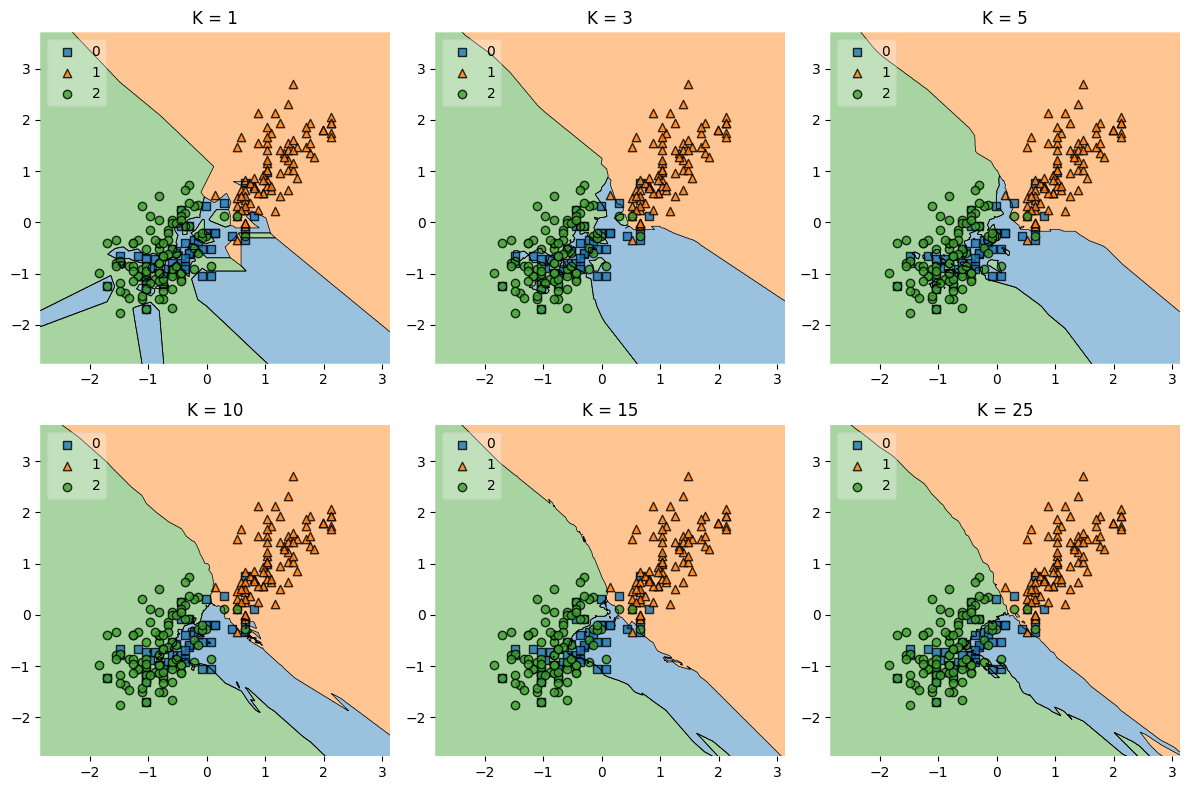

In [24]:
# В примере пингвинчики закодированы в алфавитном порядке, ваш вариант будет отличаться.
import itertools
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 3)  # 2 * 3 = 6

for clf, (r, c) in zip(classifiers, itertools.product(range(2), range(3))):
    ax = plt.subplot(gs[r, c])
    plot_decision_regions(X2_train_scaled, y2_train, clf=clf, legend=2, ax=ax)
    ax.set_title(f"K = {clf.n_neighbors}")

plt.tight_layout()
plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

In [25]:
# Судя по точности количество в 10-15 кажется оптимальным
# На графике видно, что к=1 буквально запоминает обучающую выборку и рисует ненужные области для некоторых объектов, что свидетельствует о переобучении
# k=25 видно, как сглаживаются углы и синие пингвины из дельта окресности (-1,-1) классифицируются неправильно

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

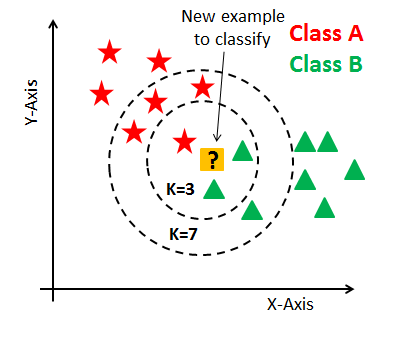

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [26]:
import numpy as np
from collections import Counter

class KNN:

    def __init__(self, k:int):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
      self.X_train = np.array(X)
      self.y_train = np.array(y)

    def predict(self, X):
        X_test = np.array(X)
        y_pred = []
        for x in X_test:
            distances = np.linalg.norm(self.X_train - x, axis=1)
            neighbors_idx = np.argsort(distances)[:self.k]
            neighbor_classes = self.y_train[neighbors_idx]
            c = Counter(neighbor_classes).most_common(1)[0][0]
            y_pred.append(c)
        return np.array(y_pred)

In [27]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [28]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [36]:
# просто решил скопировать уже имеющийся и заменить в нем классификатор на собственный
neighbors_list = range(1, 21)
train_accuracies = []
test_accuracies = []

mx, best_k = 0, 1
for k in neighbors_list:
    knn = KNN(k=k)
    knn.fit(X_train_scaled, y_train)
    
    y_train_pred = knn.predict(X_train_scaled)
    y_test_pred = knn.predict(X_test_scaled)
    
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test  = accuracy_score(y_test, y_test_pred)
    
    train_accuracies.append(acc_train)
    test_accuracies.append(acc_test)

    if acc_test > mx:
        mx = acc_test
        best_k = k


results = pd.DataFrame({
    "k": neighbors_list,
    "train_acc": train_accuracies,
    "test_acc": test_accuracies
})
print(results)
print("Лучшее k: ", best_k)
# вышло хорошо по-моему

     k  train_acc  test_acc
0    1   1.000000  0.989796
1    2   1.000000  0.989796
2    3   0.991189  1.000000
3    4   1.000000  0.989796
4    5   0.991189  1.000000
5    6   1.000000  0.989796
6    7   1.000000  0.989796
7    8   1.000000  0.989796
8    9   0.991189  0.989796
9   10   0.991189  0.989796
10  11   0.991189  0.989796
11  12   0.991189  0.989796
12  13   0.982379  0.989796
13  14   0.986784  0.989796
14  15   0.973568  0.979592
15  16   0.977974  0.979592
16  17   0.964758  0.979592
17  18   0.973568  0.979592
18  19   0.973568  0.979592
19  20   0.973568  0.979592
Лучшее k:  3


### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv('diamonds.csv')
df.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [55]:
print(df.isnull().sum())
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)
df.dropna(inplace=True)
print(df.columns)
df.head()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64
Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='object')


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

In [56]:
numeric_cols = ["carat", "depth", "table", "price", "x", "y", "z"]
df_numeric = df[numeric_cols]
corr_matrix = df_numeric.corr()
print(corr_matrix)

          carat     depth     table     price         x         y         z
carat  1.000000  0.028224  0.181618  0.921591  0.975094  0.951722  0.953387
depth  0.028224  1.000000 -0.295779 -0.010647 -0.025289 -0.029341  0.094924
table  0.181618 -0.295779  1.000000  0.127134  0.195344  0.183760  0.150929
price  0.921591 -0.010647  0.127134  1.000000  0.884435  0.865421  0.861249
x      0.975094 -0.025289  0.195344  0.884435  1.000000  0.974701  0.970772
y      0.951722 -0.029341  0.183760  0.865421  0.974701  1.000000  0.952006
z      0.953387  0.094924  0.150929  0.861249  0.970772  0.952006  1.000000


**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [57]:
cat_cols = ["cut", "color", "clarity"]
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)
df_encoded.head()

,carat,depth,table,price,x,y,z,cut_Fair,cut_Good,cut_Ideal,...,color_I,color_J,clarity_I1,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,False,True,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,False,True,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,False,...,True,False,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,False,True,False,...,False,True,False,False,False,True,False,False,False,False


**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [58]:
y = df_encoded["price"].values
X = df_encoded.drop(columns=["price"]).values
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=52
)

**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [59]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Коэффициенты лин регрессии приведутся к единому масштабу чтобы было быстрее из них чето понять

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [60]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_train_pred = lr.predict(X_train_scaled)
y_test_pred  = lr.predict(X_test_scaled)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test, y_test_pred)

print(f"MSE train: {mse_train:.2f}")
print(f"MSE test: {mse_test:.2f}")

MSE train: 1283859.07
MSE test: 1261612.96


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [ ]:
print("Wo", lr.intercept_)
print("Coefs, len coefs", lr.coef_, len(lr.coef_))

coefs = lr.coef_
intercept = lr.intercept_
feature_names = df_encoded.drop(columns=["price"]).columns
abs_coefs = np.abs(coefs)
sorted_idx = np.argsort(abs_coefs)[::-1]
print("Top 5 features:")
for i in sorted_idx[:5]:
    print(f"{feature_names[i]}: coef={coefs[i]:.3f}")
# да кто то любит эти караты я в шокере

Wo 3929.024842417425
Coefs, len coefs [ 5.27954798e+03 -9.62756062e+01 -6.58087856e+01 -1.07577149e+03
  7.98339447e-01 -2.87673144e+01 -1.29438353e+02 -3.71982813e+01
  5.13407865e+01  1.70591523e+01  3.80003893e-01  2.06252481e+02
  1.60727894e+02  1.32361716e+02  5.73887664e+01 -1.23110176e+02
 -2.48681138e+02 -3.82552207e+02 -4.75971481e+02  2.31215154e+02
 -1.47275073e+02 -4.93721798e+02  2.08596172e+02  1.10106933e+02
  2.45534089e+02  2.82444175e+02] 26
Top 5 features:
carat: coef=5279.548
x: coef=-1075.771
clarity_SI2: coef=-493.722
clarity_I1: coef=-475.971
color_J: coef=-382.552


**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [ ]:
from sklearn.linear_model import Lasso, Ridge

alpha_val = 10

lasso = Lasso(alpha=alpha_val, random_state=52)
lasso.fit(X_train_scaled, y_train)

print(lasso.coef_, lasso.intercept_)

ridge = Ridge(alpha=alpha_val, random_state=52)
ridge.fit(X_train_scaled, y_train)

print(ridge.coef_, ridge.intercept_)

# ridge веса слегка уменьшились, в то время как lasso значительно уменьшились

[4816.00721037  -62.96416659  -52.1216894  -619.47879486   -0.
  -41.50109777 -130.50835182  -38.4638072    41.48945702    0.
   -0.          142.23690984   90.5706356    61.71294922   -0.
 -165.56442374 -277.13404289 -398.64693769 -493.38838993  178.25761412
 -260.65116606 -583.97811535  101.60821065   -0.          175.27792628
  199.08993774] 3929.0248424174288
[ 5.24278388e+03 -9.37095799e+01 -6.55154380e+01 -1.03353567e+03
 -1.58304547e+00 -3.29279598e+01 -1.29609597e+02 -3.72969949e+01
  5.13392832e+01  1.70686152e+01  5.09871341e-01  2.05992353e+02
  1.60519555e+02  1.31917684e+02  5.71172803e+01 -1.22835765e+02
 -2.48052848e+02 -3.81839686e+02 -4.75443920e+02  2.31574271e+02
 -1.47815782e+02 -4.93603106e+02  2.08425305e+02  1.09929495e+02
  2.46015408e+02  2.82705525e+02] 3929.0248424174256


**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

/home/rnsns/hse/iad/iad-intro-ds/2025/homeworks/.venv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.551e+08, tolerance: 5.990e+07
  model = cd_fast.enet_coordinate_descent(


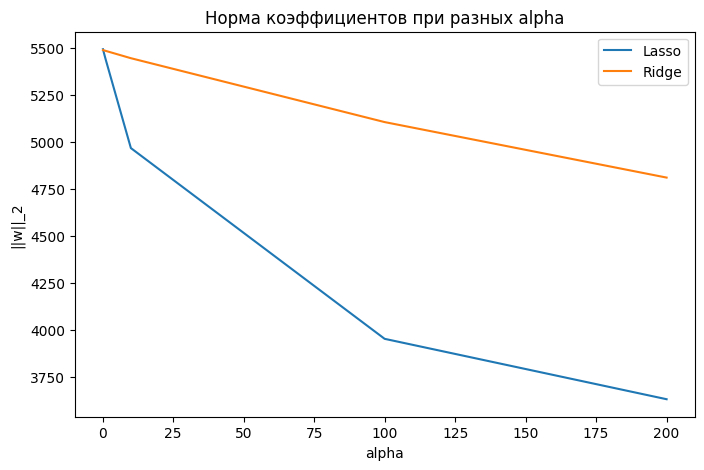

In [ ]:
alphas = [0.1, 1, 10, 100, 200]
lasso_norms = []
ridge_norms = []

for a in alphas:
    lasso_model = Lasso(alpha=a, random_state=52)
    lasso_model.fit(X_train_scaled, y_train)
    norm_lasso = np.linalg.norm(lasso_model.coef_, ord=2)
    lasso_norms.append(norm_lasso)
    ridge_model = Ridge(alpha=a, random_state=52)
    ridge_model.fit(X_train_scaled, y_train)
    norm_ridge = np.linalg.norm(ridge_model.coef_, ord=2)
    ridge_norms.append(norm_ridge)

plt.figure(figsize=(8, 5))
plt.plot(alphas, lasso_norms, label="Lasso")
plt.plot(alphas, ridge_norms, label="Ridge")
plt.xlabel("alpha")
plt.ylabel("||w||_2")
plt.legend()
plt.title("Норма коэффициентов при разных alpha")
plt.show()
# лассо быстрее уменьшает норму
# используют лассо, так как оно зануляет признаки, что позволяет отсеять ненужные, как, например, вышло выше

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [69]:
from sklearn.linear_model import LassoCV

alphas_cv = [0.01, 0.1, 1, 10, 50, 100, 200, 300, 500]
lasso_cv = LassoCV(alphas=alphas_cv, cv=5, random_state=52)
lasso_cv.fit(X_train_scaled, y_train)
print(lasso_cv.alphas_)
print("mse_path_.shape =", lasso_cv.mse_path_.shape)
best_alpha = lasso_cv.alpha_
print("best alpha=", best_alpha)
mse_means = lasso_cv.mse_path_.mean(axis=1)
for a, m in zip(lasso_cv.alphas_, mse_means):
    print(f"alpha={a:.2f}, mse mean={m:.2f}")

[5.e+02 3.e+02 2.e+02 1.e+02 5.e+01 1.e+01 1.e+00 1.e-01 1.e-02]
mse_path_.shape = (9, 5)
best alpha= 1.0
alpha=500.00, mse mean=2656930.94
alpha=300.00, mse mean=2304817.10
alpha=200.00, mse mean=1949066.59
alpha=100.00, mse mean=1536605.71
alpha=50.00, mse mean=1397182.53
alpha=10.00, mse mean=1299105.22
alpha=1.00, mse mean=1288418.13
alpha=0.10, mse mean=1288419.42
alpha=0.01, mse mean=1288473.25


**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [72]:
final_alpha = lasso_cv.alpha_
final_lasso = Lasso(alpha=final_alpha, random_state=52)
final_lasso.fit(X_train_scaled, y_train)
coefs = final_lasso.coef_
feature_names = df_encoded.drop(columns=["price"]).columns
for name, w in zip(feature_names, coefs):
    print(f"{name} -> {w:.4f}")

n_zero = np.sum(coefs == 0)
print("Число зануленных коэффициентов:", n_zero)
# ну тут все ясно - чем больше карат и размер, тем выше цена, все остальное - так себе по важности, как и в жизни (я шарю за алмазы, много у меня их в майнкрафте) 

carat -> 5233.7079
depth -> -92.9574
table -> -64.4425
x -> -1029.8695
y -> -0.0000
z -> -30.0116
cut_Fair -> -135.5373
cut_Good -> -47.3719
cut_Ideal -> 33.1980
cut_Premium -> 0.0000
cut_Very Good -> -14.2240
color_D -> 158.1138
color_E -> 105.3241
color_F -> 77.3691
color_G -> -0.0000
color_H -> -172.8277
color_I -> -289.4956
color_J -> -412.1539
clarity_I1 -> -505.5347
clarity_IF -> 184.1697
clarity_SI1 -> -259.6542
clarity_SI2 -> -592.0063
clarity_VS1 -> 113.4187
clarity_VS2 -> -0.0000
clarity_VVS1 -> 179.7216
clarity_VVS2 -> 205.0092
Число зануленных коэффициентов: 4


**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [74]:
y_test_pred_lasso = final_lasso.predict(X_test_scaled)
mse_test_lasso = mean_squared_error(y_test, y_test_pred_lasso)
print("MSE", mse_test_lasso) 
# Для предсказаний лучше использовать модель из задачи 3.7, потому что mse у нее пониже. 
# Так произошло, потому что мы оценивали mse по выборке train, и выбрали модель с мин mse на ней, но она показала mse на test похуже.

MSE 1262491.3091618847
